# Library and Dataset

In [ ]:
!pip install split-folders pillow ultralytics
!pip install roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="4kCXQVv3472M9OQVjdSg")
project = rf.workspace("pelota-fzva7").project("muro_confinado")
version = project.version(3)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Muro_Confinado-3 in yolov11:: 100%|██████████| 440/440 [00:00<00:00, 4947.36it/s]


In [ ]:
# Specify the path to the file
file_path = '/content/Muro_Confinado-3/data.yaml'

# Check if the file exists
if os.path.exists(file_path):
    print(f"The file at {file_path} exists.")
else:
    print(f"The file at {file_path} does not exist.")

The file at /content/Muro_Confinado-3/data.yaml exists.


In [ ]:
# Get the current working directory
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

# List all files and directories in the current directory
files = os.listdir(cwd)
print(f"Files and directories in '{cwd}': {files}")

Current working directory: /content
Files and directories in '/content': ['.config', 'Muro_Confinado-3', 'sample_data']


In [ ]:
# Remove unnecessary data
dir_path = cwd + "/sample_data"
for files in os.listdir(dir_path):
  os.remove(dir_path + "/" + files)
os.rmdir(dir_path)

# Load pre-trained model

In [ ]:
# YOLOv11 Large pre-training load
from ultralytics import YOLO
model = YOLO("yolo11l.pt")
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO11l summary: 357 layers, 25,372,160 parameters, 0 gradients, 87.6 GFLOPs


(357, 25372160, 0, 87.6134912)

In [ ]:
from ultralytics import settings

# View all settings

settings.update({'datasets_dir': '/content/Muro_Confinado-3'})

# Training Model

In [ ]:

model.train(
    data='/content/Muro_Confinado-3/data.yaml',
    epochs=200,
    imgsz=1024,
    batch=4,
    name="entrenamiento_confined_masonry",
    project="proyecto_confined"
)


Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Muro_Confinado-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=entrenamiento_confined_masonry, nbs=64, nms=False, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7f9a25bd70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import os

# List files in the directory
directory = "/content/runs/detect/proyecto_confined/entrenamiento_confined_masonry"
if os.path.exists(directory):
    print("Archivos en el directorio:")
    print(os.listdir(directory))
else:
    print(f"El directorio {directory} no existe.")

Archivos en el directorio:
['confusion_matrix_normalized.png', 'results.png', 'weights', 'val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'train_batch2.jpg', 'train_batch1.jpg', 'args.yaml', 'train_batch9880.jpg', 'val_batch0_pred.jpg', 'BoxF1_curve.png', 'train_batch9881.jpg', 'BoxP_curve.png', 'BoxR_curve.png', 'val_batch1_pred.jpg', 'train_batch9882.jpg', 'results.csv', 'train_batch0.jpg', 'labels.jpg', 'BoxPR_curve.png', 'confusion_matrix.png']


# Metrics and Grafics

In [ ]:
# DataFrame of training metrics
df_metrics = pd.read_csv("/content/runs/detect/proyecto_confined/entrenamiento_confined_masonry/results.csv")

# Show some metrics
print(df_metrics.head(5))

print(df_metrics.index.to_list())
print(df_metrics.columns.to_list())

df_metrics.describe()

   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  22.5317         0.96743         1.87698         1.37174   
1      2  32.1290         0.89182         1.26057         1.22623   
2      3  41.4459         1.17248         1.44119         1.43500   
3      4  50.6856         1.14696         1.32158         1.46592   
4      5  60.0220         0.89254         1.21042         1.29623   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.02184            0.46078           0.01332   
1               0.00000            0.00000           0.00000   
2               0.00353            0.00980           0.00002   
3               0.00000            0.00000           0.00000   
4               0.79618            0.88085           0.88796   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.00724       1.17216       47.7204       1.93893  0.000654   
1              0.00000           NaN        

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,192.000000,192.000000,192.000000,200.000000,200.000000,200.000000
mean,100.500000,957.082116,0.372232,0.359999,0.926828,0.958243,0.965301,0.961999,0.910695,0.341425,0.477219,0.830197,0.001005,0.001005,0.001005
std,57.879185,543.272177,0.145456,0.222399,0.092301,0.161541,0.159098,0.168911,0.165232,0.082747,3.428272,0.088514,0.000565,0.000565,0.000565
min,1.000000,22.531700,0.205430,0.165520,0.823620,0.000000,0.000000,0.000000,0.000000,0.277330,0.160170,0.797540,0.000030,0.000030,0.000030
25%,50.750000,490.624500,0.287517,0.247950,0.880115,0.987268,0.990343,0.994810,0.936895,0.308118,0.179172,0.809740,0.000522,0.000522,0.000522
50%,100.500000,956.880500,0.338595,0.303940,0.903765,0.990265,1.000000,0.995000,0.948565,0.320255,0.204185,0.815515,0.001005,0.001005,0.001005
75%,150.250000,1423.657500,0.407665,0.389848,0.940063,0.996067,1.000000,0.995000,0.954557,0.343963,0.250095,0.827542,0.001488,0.001488,0.001488
max,200.000000,1891.210000,1.172480,1.876980,1.465920,1.000000,1.000000,0.995000,0.966150,1.172160,47.720400,1.938930,0.001970,0.001970,0.001970


['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


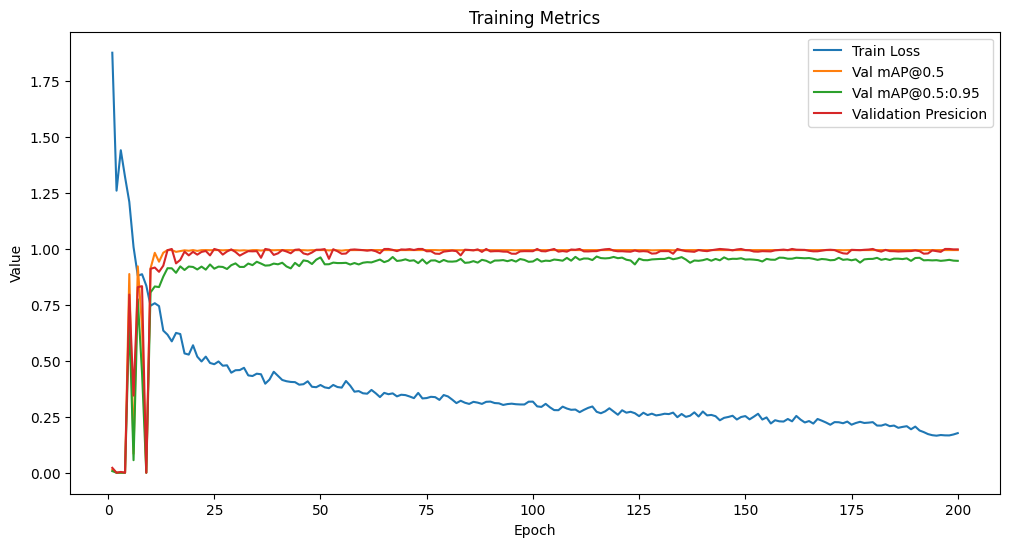

In [ ]:
print(df_metrics.columns.to_list())
# Graficar las métricas
plt.figure(figsize=(12, 6))
plt.plot(df_metrics[['epoch']], df_metrics[['train/cls_loss']], label='Train Loss')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50(B)']], label='Val mAP@0.5')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50-95(B)']], label='Val mAP@0.5:0.95')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/precision(B)']], label='Validation Presicion')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [ ]:
# Evaluate
results = model.val()

# Show Results
print(results)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2007.6±1056.0 MB/s, size: 89.8 KB)
val: Scanning /content/Muro_Confinado-3/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all         10        102       0.99          1      0.995      0.969
Speed: 2.0ms preprocess, 16.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7f966aa720>
curves: ['Precision-Recall(B)', 'F1-C

In [ ]:
# Evaluate

best_model = YOLO("/content/runs/detect/proyecto_confined/entrenamiento_confined_masonry/weights/best.pt")
results2 = best_model.val()

# Show Results
print(results2)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2717.7±849.5 MB/s, size: 92.9 KB)
val: Scanning /content/Muro_Confinado-3/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all         10        102       0.99          1      0.995      0.969
Speed: 2.1ms preprocess, 9.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7fa0dfe750>
curves: ['Precision-Recall(B)', 'F1-C

In [ ]:
# Evaluate

last_model = YOLO("/content/runs/detect/proyecto_confined/entrenamiento_confined_masonry/weights/last.pt")
results3 = last_model.val()

# Show Results
print(results3)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2401.2±604.2 MB/s, size: 93.9 KB)
val: Scanning /content/Muro_Confinado-3/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3it/s 0.3s
                   all         10        102      0.998          1      0.995       0.95
Speed: 2.0ms preprocess, 9.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7fb1ab8050>
curves: ['Precision-Recall(B)', 'F1-C

# Load trained model

In [ ]:
# Load Model
# modelo_entrenado = YOLO("/content/yolov8n.pt")
modelo_entrenado = YOLO("/content/runs/detect/proyecto_confined/entrenamiento_confined_masonry/weights/best.pt")


# Show Predictions

In [ ]:

resultados = modelo_entrenado.predict(source="/content/Muro_Confinado-3/valid/images/v2_png.rf.271e32ed0a461663278d316cf8fc3118.jpg", save=True)

for resultado in resultados:
    print(f"Predicciones para la imagen: {resultado.path}")

    for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
        print(f"Bounding Box: {caja} - Confianza: {conf} - Clase: {clase}")


image 1/1 /content/Muro_Confinado-3/valid/images/v2_png.rf.271e32ed0a461663278d316cf8fc3118.jpg: 1024x1024 13 Muro-Confinados, 20.1ms
Speed: 4.2ms preprocess, 20.1ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/detect/predict
Predicciones para la imagen: /content/Muro_Confinado-3/valid/images/v2_png.rf.271e32ed0a461663278d316cf8fc3118.jpg
Bounding Box: tensor([620.8625, 556.8694, 781.6423, 716.4484], device='cuda:0') - Confianza: 0.924728512763977 - Clase: 0.0
Bounding Box: tensor([621.8528, 724.9031, 779.9700, 880.4028], device='cuda:0') - Confianza: 0.9236848950386047 - Clase: 0.0
Bounding Box: tensor([ 32.9781, 722.8628, 181.1078, 878.8118], device='cuda:0') - Confianza: 0.9226816296577454 - Clase: 0.0
Bounding Box: tensor([496.0959, 723.5227, 608.7852, 880.2009], device='cuda:0') - Confianza: 0.9222946166992188 - Clase: 0.0
Bounding Box: tensor([278.2046, 724.5878, 482.6532, 880.0665], device='cuda:0') - Confianza: 0.92167079448

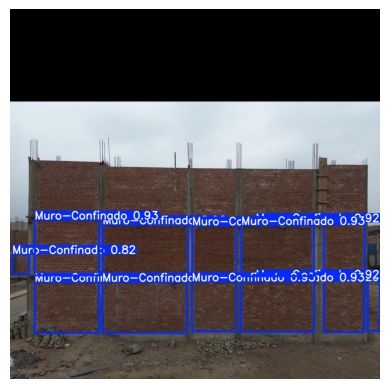

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/a1_png.rf.8277c16885fafcdfba218c2e68431ac8.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

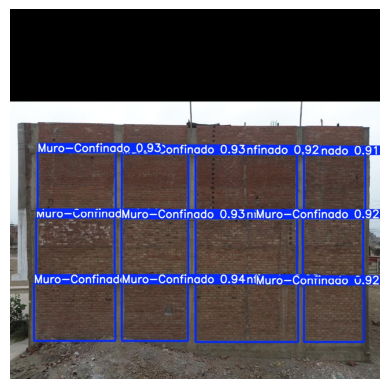

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/a6_png.rf.202bfad5b99abff1694ab8f8faedf4f2.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

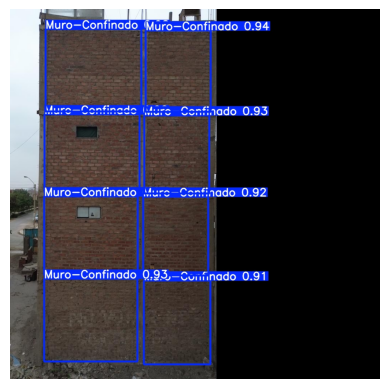

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/a7_png.rf.25559d142267ad61776105ce8fcf1d8b.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

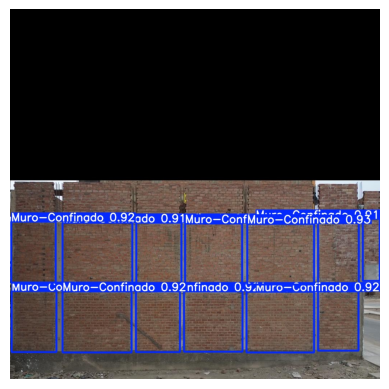

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/a8_png.rf.9424dfa6cb6a5e04970d6b1d52e68d90.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

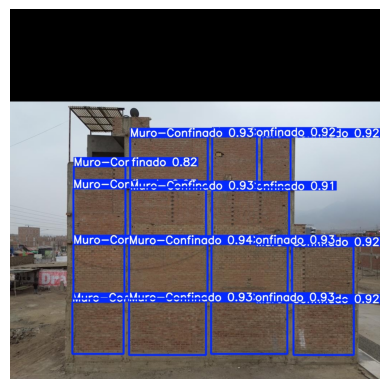

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/v1_png.rf.52903337bb332fe3a36b0c063cf90477.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

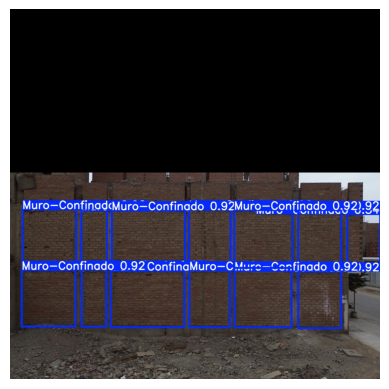

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/v2_png.rf.271e32ed0a461663278d316cf8fc3118.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

# Download Results

In [ ]:
import shutil
from google.colab import files

# Especifica el nombre de la carpeta que deseas comprimir y descargar
folder_path = "/content/runs/detect/proyecto_confined"  # Ruta de la carpeta en Colab
output_filename = "version.zip"   # Nombre del archivo zip de salida

# Comprimir la carpeta en un archivo ZIP
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', folder_path)

# Descargar el archivo ZIP
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

# Especifica el nombre de la carpeta que deseas comprimir y descargar
folder_path = "/content/runs/detect/val"  # Ruta de la carpeta en Colab
output_filename = "version2.zip"   # Nombre del archivo zip de salida

# Comprimir la carpeta en un archivo ZIP
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', folder_path)

# Descargar el archivo ZIP
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>